Polynomial Fit (degree = 3 )
Coefficients: [ 0.07407407 -0.55555556  1.1005291   0.06349206]
MSE: 0.16931216931216939
R^2: 0.32275132275132246

Cubic Spline
MSE: 0.0
R^2: 1.0


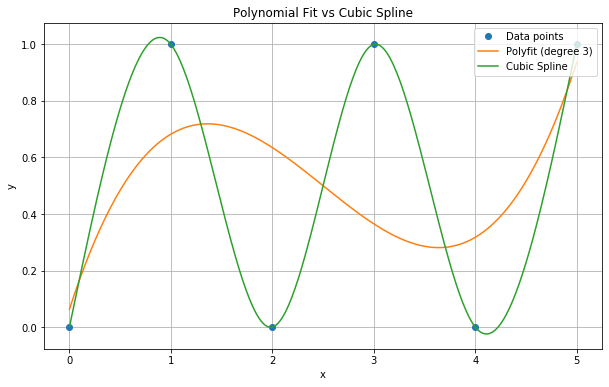

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

cs = CubicSpline(x, y, bc_type='natural')

degree = 3
coeffs = np.polyfit(x, y, degree)
poly = np.poly1d(coeffs)

x_interp = np.linspace(0, 5, 300)
y_spline = cs(x_interp)
y_poly = poly(x_interp)

y_poly_data = poly(x)
y_spline_data = cs(x)

mse_poly = np.mean((y - y_poly_data)**2)
mse_spline = np.mean((y - y_spline_data)**2)

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

r2_poly = r_squared(y, y_poly_data)
r2_spline = r_squared(y, y_spline_data)

print("Polynomial Fit (degree =", degree, ")")
print("Coefficients:", coeffs)
print("MSE:", mse_poly)
print("R^2:", r2_poly)

print("\nCubic Spline")
print("MSE:", mse_spline)
print("R^2:", r2_spline)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o', label='Data points')
plt.plot(x_interp, y_poly, label=f'Polyfit (degree {degree})')
plt.plot(x_interp, y_spline, label='Cubic Spline')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Fit vs Cubic Spline')
plt.legend()
plt.grid(True)
plt.show()
